# Final Model Analysis

In this notebook, the selected Random Forest model is analyzed in greater detail.

The analysis focuses on classification errors, the confusion matrix, detailed class-level performance, and the most important network traffic features used by the model.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
# Load the cleaned dataset

data_path = "../data/processed/portscan_clean.csv"

df = pd.read_csv(data_path)

print("Clean dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nClass distribution:")
print(df["Label"].value_counts())

Clean dataset loaded successfully!
Dataset shape: (213777, 79)

Class distribution:
Label
BENIGN      123083
PortScan     90694
Name: count, dtype: int64


In [10]:
# Prepare features and target

X = df.drop(columns=["Label"])

y = df["Label"].map({
    "BENIGN": 0,
    "PortScan": 1
})

# Split the dataset exactly as before
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 171021
Testing samples: 42756

Training class distribution:
Label
0    98466
1    72555
Name: count, dtype: int64

Testing class distribution:
Label
0    24617
1    18139
Name: count, dtype: int64


In [11]:
# Train the final Random Forest model

final_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train, y_train)

print("Final Random Forest model trained successfully!")

Final Random Forest model trained successfully!


In [12]:
# Make predictions using the final Random Forest model

y_pred_final = final_rf.predict(X_test)

print("Prediction completed!")
print("Number of predictions:", len(y_pred_final))

Prediction completed!
Number of predictions: 42756


In [13]:
# Confusion Matrix for the final Random Forest model

cm_final = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm_final)

Confusion Matrix:
[[24617     0]
 [    4 18135]]


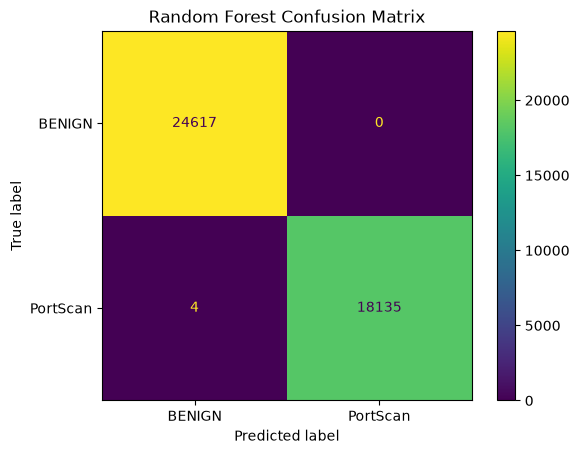

In [14]:
# Visualize the Confusion Matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["BENIGN", "PortScan"]
)

disp.plot(values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [15]:
# Detailed classification report

report = classification_report(
    y_test,
    y_pred_final,
    target_names=["BENIGN", "PortScan"]
)

print("Random Forest Classification Report")
print("-----------------------------------")
print(report)

Random Forest Classification Report
-----------------------------------
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     24617
    PortScan       1.00      1.00      1.00     18139

    accuracy                           1.00     42756
   macro avg       1.00      1.00      1.00     42756
weighted avg       1.00      1.00      1.00     42756



In [16]:
# Detailed classification report with 4 decimal places

print("Random Forest Classification Report")
print("-----------------------------------")

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["BENIGN", "PortScan"],
        digits=4
    )
)

Random Forest Classification Report
-----------------------------------
              precision    recall  f1-score   support

      BENIGN     0.9998    1.0000    0.9999     24617
    PortScan     1.0000    0.9998    0.9999     18139

    accuracy                         0.9999     42756
   macro avg     0.9999    0.9999    0.9999     42756
weighted avg     0.9999    0.9999    0.9999     42756



In [17]:
# Calculate feature importance

feature_importance_final = pd.Series(
    final_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance_final.head(15))

Top 15 Most Important Features:
Flow IAT Max                   0.067407
Subflow Fwd Bytes              0.065764
Fwd Packet Length Mean         0.062351
Bwd Packets/s                  0.061594
Average Packet Size            0.058808
Total Length of Fwd Packets    0.053091
Fwd Packet Length Max          0.050691
PSH Flag Count                 0.048647
Packet Length Mean             0.048397
Packet Length Std              0.045603
Flow Duration                  0.044349
Avg Fwd Segment Size           0.040913
Subflow Fwd Packets            0.037436
Max Packet Length              0.032046
ACK Flag Count                 0.022461
dtype: float64


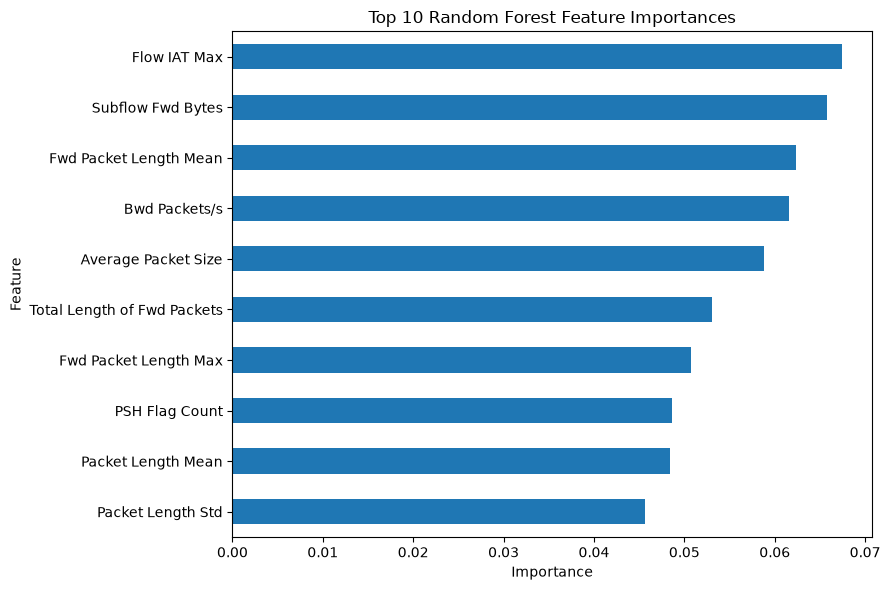

In [18]:
# Plot Top 10 Feature Importances

top_features_final = feature_importance_final.head(10)

plt.figure(figsize=(9, 6))

top_features_final.sort_values().plot(kind="barh")

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

In [19]:
# Final performance metrics

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)

print("Final Random Forest Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy_final:.6f}")
print(f"Precision: {precision_final:.6f}")
print(f"Recall   : {recall_final:.6f}")
print(f"F1-score : {f1_final:.6f}")

Final Random Forest Performance
--------------------------------
Accuracy : 0.999906
Precision: 1.000000
Recall   : 0.999779
F1-score : 0.999890


## Final Model Analysis Summary

The Random Forest classifier demonstrated excellent performance in detecting PortScan network attacks.

The final model achieved an accuracy of 99.9906%, a precision of 100%, a recall of 99.9779%, and an F1-score of 99.9890%.

The confusion matrix showed that only 4 out of 42,756 test samples were misclassified. In particular, the model produced no false-positive PortScan detections in this test split, while four actual PortScan samples were classified as benign.

Feature importance analysis showed that Flow IAT Max, Subflow Fwd Bytes, Fwd Packet Length Mean, Bwd Packets/s, and Average Packet Size were among the most influential network traffic features.

Overall, the results indicate that the Random Forest model provides highly accurate classification performance on the evaluated PortScan dataset.

In [20]:
from pathlib import Path
import joblib

# Create the models directory
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save the trained Random Forest model
model_path = models_dir / "random_forest_portscan.joblib"

joblib.dump(final_rf, model_path)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: ..\models\random_forest_portscan.joblib


In [21]:
# Create results directory

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

# Save final performance metrics

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Score": [
        accuracy_final,
        precision_final,
        recall_final,
        f1_final
    ]
})

metrics_path = results_dir / "metrics.csv"
metrics.to_csv(metrics_path, index=False)

print(metrics)
print("\nMetrics saved to:", metrics_path)

      Metric     Score
0   Accuracy  0.999906
1  Precision  1.000000
2     Recall  0.999779
3   F1-score  0.999890

Metrics saved to: ..\results\metrics.csv


In [22]:
feature_importance_df = (
    feature_importance_final
    .reset_index()
)

feature_importance_df.columns = [
    "Feature",
    "Importance"
]

feature_path = results_dir / "feature_importance.csv"

feature_importance_df.to_csv(
    feature_path,
    index=False
)

print("Feature importance saved successfully!")
print("Path:", feature_path)

feature_importance_df.head(10)

Feature importance saved successfully!
Path: ..\results\feature_importance.csv


,Feature,Importance
0,Flow IAT Max,0.067407
1,Subflow Fwd Bytes,0.065764
2,Fwd Packet Length Mean,0.062351
3,Bwd Packets/s,0.061594
4,Average Packet Size,0.058808
5,Total Length of Fwd Packets,0.053091
6,Fwd Packet Length Max,0.050691
7,PSH Flag Count,0.048647
8,Packet Length Mean,0.048397
9,Packet Length Std,0.045603


In [23]:
# Create figures directory
figures_dir = Path("../results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

print("Figures directory created successfully!")
print("Path:", figures_dir)

Figures directory created successfully!
Path: ..\results\figures


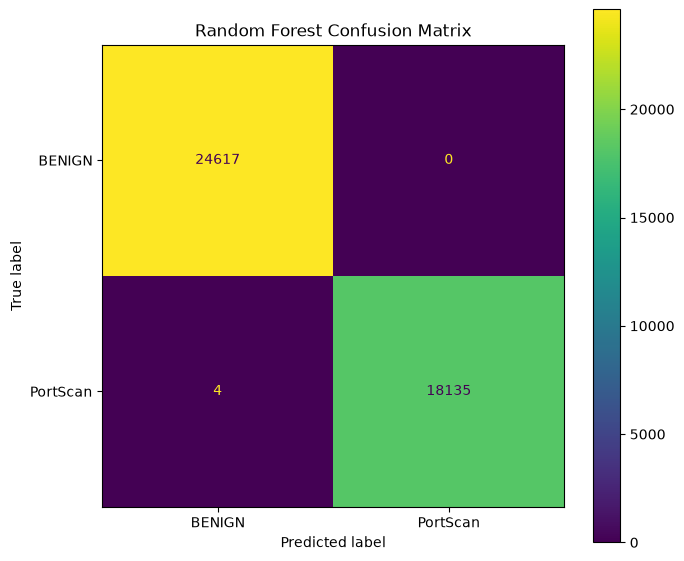

Confusion matrix saved to: ..\results\figures\confusion_matrix.png


In [24]:
# Save Confusion Matrix figure

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["BENIGN", "PortScan"]
)

disp.plot(ax=ax, cmap="viridis", values_format="d")

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()

confusion_path = figures_dir / "confusion_matrix.png"
plt.savefig(confusion_path, dpi=300, bbox_inches="tight")

plt.show()

print("Confusion matrix saved to:", confusion_path)

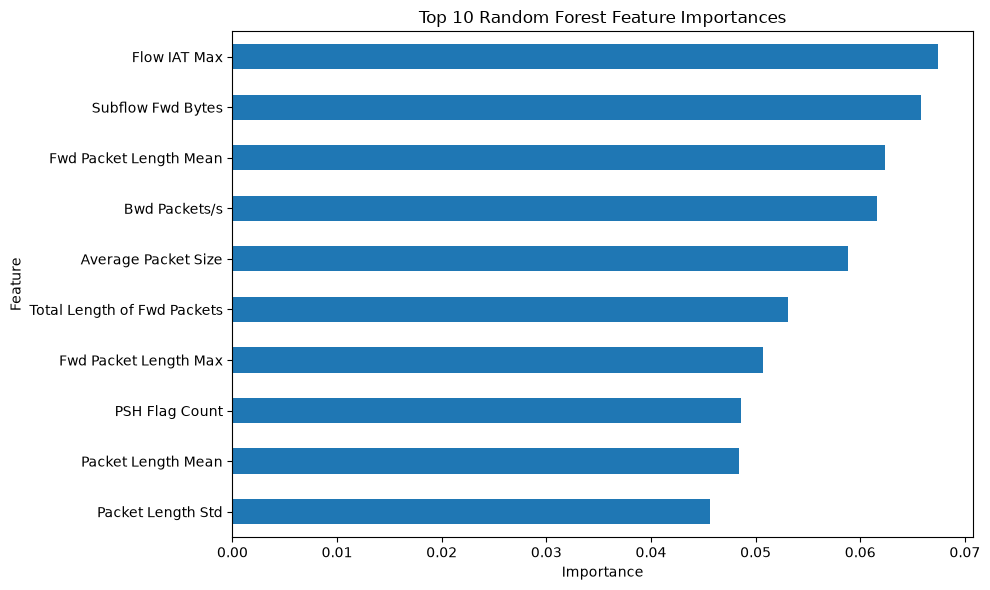

Feature importance figure saved to: ..\results\figures\feature_importance.png


In [25]:
# Save Feature Importance figure

top_10 = feature_importance_final.head(10).sort_values()

plt.figure(figsize=(10, 6))
top_10.plot(kind="barh")

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

feature_plot_path = figures_dir / "feature_importance.png"
plt.savefig(feature_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Feature importance figure saved to:", feature_plot_path)

In [26]:
# Save classification report to a text file

from sklearn.metrics import classification_report
import os

report_path = "../results/classification_report.txt"

report = classification_report(
    y_test,
    y_pred_final,
    target_names=["BENIGN", "PortScan"],
    digits=4
)

with open(report_path, "w") as f:
    f.write("Random Forest Classification Report\n")
    f.write("===================================\n\n")
    f.write(report)

print("Classification report saved to:", report_path)

Classification report saved to: ../results/classification_report.txt


In [29]:
import os

print("gitignore exists:", os.path.exists("../.gitignore"))

if os.path.exists("../.gitignore"):
    with open("../.gitignore", "r") as f:
        print("\n.gitignore content:\n")
        print(f.read())

gitignore exists: True

.gitignore content:

# Python
__pycache__/
*.pyc
*.pyo
*.pyd

# Jupyter
.ipynb_checkpoints/

# Environment
venv/
env/
.venv/

# Large/raw datasets
data/raw/

# Operating system files
.DS_Store
Thumbs.db

# Temporary files
*.tmp
*.log


In [30]:
import os

extra_file = "../gitignore.txt"

if os.path.exists(extra_file):
    os.remove(extra_file)
    print("Extra gitignore.txt removed successfully!")
else:
    print("No extra file found.")

Extra gitignore.txt removed successfully!


In [32]:
from pathlib import Path

readme_path = Path("../README.md")

readme_content = r"""
# Network Intrusion Anomaly Detection

A machine learning project for detecting PortScan attacks in network traffic using the CICIDS2017 dataset.

## Project Overview

This project focuses on distinguishing benign network traffic from PortScan activity using supervised machine learning.

The workflow includes:

- Data cleaning and preprocessing
- Exploratory data analysis
- Baseline model training
- Comparison of multiple classifiers
- Final Random Forest evaluation
- Feature importance analysis
- Saving the trained model and evaluation results

## Dataset

The project uses the PortScan subset of the CICIDS2017 dataset.

After preprocessing, the cleaned dataset contained:

- 213,777 network flows
- 78 predictive features
- 123,083 BENIGN samples
- 90,694 PortScan samples

## Models Evaluated

Three classification models were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Random Forest achieved the strongest overall performance and was selected as the final model.

## Final Model Performance

| Metric | Score |
|---|---:|
| Accuracy | 0.999906 |
| Precision | 1.000000 |
| Recall | 0.999779 |
| F1-score | 0.999890 |

The final confusion matrix was:

    [[24617     0]
     [    4 18135]]

Only four PortScan samples were incorrectly classified as BENIGN in the held-out test set.

## Important Features

The most influential features included:

1. Flow IAT Max
2. Subflow Fwd Bytes
3. Fwd Packet Length Mean
4. Bwd Packets/s
5. Average Packet Size
6. Total Length of Fwd Packets
7. Fwd Packet Length Max
8. PSH Flag Count
9. Packet Length Mean
10. Packet Length Std

## Project Structure

    network-intrusion-anomaly-detection/
    ├── data/
    ├── models/
    │   └── random_forest_portscan.joblib
    ├── notebooks/
    │   ├── 01_data_exploration.ipynb
    │   ├── 02_baseline_model.ipynb
    │   ├── 03_model_comparison.ipynb
    │   └── 04_final_model_analysis.ipynb
    ├── results/
    │   ├── figures/
    │   │   ├── confusion_matrix.png
    │   │   └── feature_importance.png
    │   ├── classification_report.txt
    │   ├── feature_importance.csv
    │   └── metrics.csv
    ├── .gitignore
    ├── requirements.txt
    └── README.md

## Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Jupyter Notebook
- Joblib

## Reproducibility

Install the required packages using:

    pip install -r requirements.txt

The raw CICIDS2017 dataset is not included in the repository because of its size.

## Notes

The reported results apply to the evaluated PortScan subset and the specified train-test split. Performance on unseen network environments or other attack categories may differ.
"""

readme_path.write_text(readme_content.strip(), encoding="utf-8")

print("README.md created successfully!")
print("Saved to:", readme_path)

README.md created successfully!
Saved to: ..\README.md


In [33]:
import os

project_root = ".."

print("Project root files:\n")

for item in sorted(os.listdir(project_root)):
    print(item)

Project root files:

.gitignore
.ipynb_checkpoints
README.md
data
models
notebooks
requirements.txt
results


In [1]:
!git --version

git version 2.55.0.windows.1


In [2]:
import os

os.chdir("..")

print("Current folder:")
print(os.getcwd())

Current folder:
C:\Users\hamahang shop\network-intrusion-anomaly-detection


In [3]:
!git init

Initialized empty Git repository in C:/Users/hamahang shop/network-intrusion-anomaly-detection/.git/


In [4]:
!git status

On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	README.md
	data/
	models/
	notebooks/
	requirements.txt
	results/

nothing added to commit but untracked files present (use "git add" to track)


In [5]:
!git status --ignored

On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	README.md
	data/
	models/
	notebooks/
	requirements.txt
	results/

Ignored files:
  (use "git add -f <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	data/raw/
	notebooks/.ipynb_checkpoints/

nothing added to commit but untracked files present (use "git add" to track)


In [6]:
!git add .